# Imports and Configuration

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Dataset configuration
dataset_path = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 16
EPOCHS = 50

# Define class names
class_names = [
    'Kalochitra', 'Anantamu', 'Apang', 'Syspan', 'Appishikha', 
    'Kalamegh', 'Kalothutura', 'Gshnru', 'Chapalish', 'Beta',
    'Punarnava', 'Bamonhati', 'Basok', 'Ramtulsi', 'Shotomuli', 'Sarpagandha'
]

print("Libraries imported and configuration set!")

2025-11-30 14:19:59.577633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764512399.814597      71 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764512399.881041      71 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Libraries imported and configuration set!


# CBAM Attention Module

In [2]:
class CBAM(keras.layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        self.channel = input_shape[-1]
        
        # Channel Attention
        self.channel_avg_pool = layers.GlobalAveragePooling2D()
        self.channel_max_pool = layers.GlobalMaxPooling2D()
        self.channel_dense1 = layers.Dense(self.channel // self.reduction_ratio, activation='relu')
        self.channel_dense2 = layers.Dense(self.channel)
        
        # Spatial Attention
        self.spatial_conv = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')
        
        super(CBAM, self).build(input_shape)

    def call(self, inputs):
        # Channel Attention
        avg_pool = self.channel_avg_pool(inputs)
        max_pool = self.channel_max_pool(inputs)
        
        avg_out = self.channel_dense2(self.channel_dense1(avg_pool))
        max_out = self.channel_dense2(self.channel_dense1(max_pool))
        
        channel_attention = tf.sigmoid(avg_out + max_out)
        channel_attention = tf.reshape(channel_attention, [-1, 1, 1, self.channel])
        
        # Apply channel attention
        x = inputs * channel_attention
        
        # Spatial Attention
        avg_pool_spatial = tf.reduce_mean(x, axis=3, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=3, keepdims=True)
        spatial_attention = tf.concat([avg_pool_spatial, max_pool_spatial], axis=3)
        spatial_attention = self.spatial_conv(spatial_attention)
        
        # Apply spatial attention
        output = x * spatial_attention
        
        return output

    def get_config(self):
        config = super(CBAM, self).get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config

print("CBAM Attention Module defined!")

CBAM Attention Module defined!


# Model Architecture

In [3]:
def build_attention_cnn_model():
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    
    # Initial Convolution Block
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Second Convolution Block with CBAM
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = CBAM(reduction_ratio=16)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Third Convolution Block
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = CBAM(reduction_ratio=16)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Fourth Convolution Block
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = CBAM(reduction_ratio=16)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Global Pooling and Fully Connected Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # Output Layer
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Build and display model
model = build_attention_cnn_model()
print("Attention-Enhanced CNN Model built successfully!")
model.summary()

I0000 00:00:1764512417.003240      71 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764512417.003845      71 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Attention-Enhanced CNN Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam (CBAM)                     │ (None, 112, 112, 64)   │           679 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam_1 (CBAM)                   │ (None, 56, 56, 128)    │         2,283 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam_2 (CBAM)                   │ (None, 28, 28, 256)    │         8,563 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,410,133 (5.38 MB)

 Trainable params: 1,407,381 (5.37 MB)

 Non-trainable params: 2,752 (10.75 KB)

# Data Generators

In [4]:
def create_data_generators():
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        brightness_range=[0.8, 1.2],
        validation_split=0.2
    )
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True
    )
    
    validation_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )
    
    return train_generator, validation_generator

print("Creating data generators...")
train_gen, val_gen = create_data_generators()

print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Number of classes: {len(train_gen.class_indices)}")

Creating data generators...
Found 2804 images belonging to 16 classes.
Found 690 images belonging to 16 classes.
Training samples: 2804
Validation samples: 690
Number of classes: 16


# Callbacks and Model Compilation

In [5]:
# Define callbacks with Early Stopping
early_stopper = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=8,
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint to save best model
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_attention_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stopper, reduce_lr, checkpoint]

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Model compiled with callbacks:")
print("- Early Stopping (patience=15)")
print("- ReduceLROnPlateau (patience=8)")
print("- ModelCheckpoint (saves best model)")

Model compiled with callbacks:
- Early Stopping (patience=15)
- ReduceLROnPlateau (patience=8)
- ModelCheckpoint (saves best model)


# Model Training

In [6]:
print("Starting model training...")
start_time = time.time()

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# Load the best model
model = keras.models.load_model('best_attention_model.h5', custom_objects={'CBAM': CBAM})
print("Best model loaded based on validation accuracy!")

Starting model training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1764512431.873439     122 service.cc:148] XLA service 0x785afc02ae40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764512431.874447     122 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764512431.874469     122 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764512433.133511     122 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/88 ━━━━━━━━━━━━━━━━━━━━ 34:30 24s/step - accuracy: 0.0625 - loss: 4.5827 - precision: 0.0000e+00 - recall: 0.0000e+00

...

88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 532ms/step - accuracy: 0.9523 - loss: 0.1818 - precision: 0.9583 - recall: 0.9482 - val_accuracy: 0.8855 - val_loss: 0.4033 - val_precision: 0.9240 - val_recall: 0.8638 - learning_rate: 0.0010
Epoch 34/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9670 - loss: 0.1037 - precision: 0.9736 - recall: 0.9636
Epoch 34: val_accuracy did not improve from 0.88551
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 534ms/step - accuracy: 0.9670 - loss: 0.1038 - precision: 0.9735 - recall: 0.9636 - val_accuracy: 0.3942 - val_loss: 7.1109 - val_precision: 0.4060 - val_recall: 0.3942 - learning_rate: 0.0010
Epoch 35/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9643 - loss: 0.1249 - precision: 0.9677 - recall: 0.9593
Epoch 35: val_accuracy did not improve from 0.88551
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 539ms/step - accuracy: 0.9643 - loss: 0.1248 - precision: 0.9677 - recall: 0.9593 - val_accuracy: 0.3058 - val_loss: 7.5953 - val_precision: 0.3139 - val_recall: 0.3043 

88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 539ms/step - accuracy: 0.9693 - loss: 0.0790 - precision: 0.9735 - recall: 0.9666 - val_accuracy: 0.8928 - val_loss: 0.3875 - val_precision: 0.9028 - val_recall: 0.8884 - learning_rate: 2.0000e-04
Epoch 41/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9849 - loss: 0.0546 - precision: 0.9862 - recall: 0.9825
Epoch 41: val_accuracy improved from 0.89275 to 0.99565, saving model to best_attention_model.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 48s 540ms/step - accuracy: 0.9849 - loss: 0.0545 - precision: 0.9863 - recall: 0.9825 - val_accuracy: 0.9957 - val_loss: 0.0165 - val_precision: 0.9971 - val_recall: 0.9957 - learning_rate: 2.0000e-04
Epoch 42/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9820 - loss: 0.0592 - precision: 0.9842 - recall: 0.9801
Epoch 42: val_accuracy did not improve from 0.99565
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 536ms/step - accuracy: 0.9820 - loss: 0.0591 - precision: 0.9842 - recall: 0.9801 - val_accuracy: 0.9725 - val_loss: 0.0737 - val_precision: 0.9738 - val_recall: 0.9710 - learning_rate: 2.0000e-04
Epoch 43/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9897 - loss: 0.0408 - precision: 0.9910 - recall: 0.9892
Epoch 43: val_accuracy did not improve from 0.99565
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 536ms/step - accuracy: 0.9897 - loss: 0.0409 - precision: 0.9909 - recall: 0.9892 - val_accuracy: 0.9638 - val_loss: 0.1252 - val_precision: 0.9650 - val_recall:

88/88 ━━━━━━━━━━━━━━━━━━━━ 48s 543ms/step - accuracy: 0.9868 - loss: 0.0335 - precision: 0.9887 - recall: 0.9860 - val_accuracy: 0.9986 - val_loss: 0.0124 - val_precision: 0.9986 - val_recall: 0.9986 - learning_rate: 2.0000e-04
Epoch 48/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9871 - loss: 0.0461 - precision: 0.9892 - recall: 0.9861
Epoch 48: val_accuracy did not improve from 0.99855
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 537ms/step - accuracy: 0.9871 - loss: 0.0462 - precision: 0.9891 - recall: 0.9861 - val_accuracy: 0.9768 - val_loss: 0.0705 - val_precision: 0.9782 - val_recall: 0.9739 - learning_rate: 2.0000e-04
Epoch 49/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9864 - loss: 0.0402 - precision: 0.9874 - recall: 0.9852
Epoch 49: val_accuracy did not improve from 0.99855
88/88 ━━━━━━━━━━━━━━━━━━━━ 47s 538ms/step - accuracy: 0.9864 - loss: 0.0402 - precision: 0.9874 - recall: 0.9852 - val_accuracy: 0.9928 - val_loss: 0.0229 - val_precision: 0.9942 - val_recall:

Best model loaded based on validation accuracy!


# Model Evaluation

In [7]:
def evaluate_model(model, val_gen, training_time):
    print("Evaluating model...")
    
    # Predict on validation set
    start_time = time.time()
    y_pred = model.predict(val_gen)
    testing_time = time.time() - start_time
    
    y_true = val_gen.classes
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_pred_proba = y_pred
    
    # Calculate metrics
    val_loss, val_accuracy, val_precision, val_recall = model.evaluate(val_gen, verbose=0)
    val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall)
    
    # Classification report
    class_report = classification_report(y_true, y_pred_classes, 
                                       target_names=class_names, output_dict=True)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)
    
    # ROC Curve and AUC
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    
    # Calculate ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Calculate macro-average AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_CLASSES
    
    macro_auc = auc(all_fpr, mean_tpr)
    
    return {
        'val_accuracy': val_accuracy,
        'val_loss': val_loss,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'classification_report': class_report,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'macro_auc': macro_auc,
        'training_time': training_time,
        'testing_time': testing_time,
        'y_true': y_true,
        'y_pred_classes': y_pred_classes,
        'y_pred_proba': y_pred_proba
    }

# Evaluate the model
results = evaluate_model(model, val_gen, training_time)
print("Model evaluation completed!")

Evaluating model...
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step
Model evaluation completed!


# Visualization Functions

In [8]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot training & validation accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot training & validation loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Attention-Enhanced CNN')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_roc_curve(fpr, tpr, roc_auc, macro_auc, class_names):
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.rainbow(np.linspace(0, 1, NUM_CLASSES))
    for i, color in zip(range(NUM_CLASSES), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label='{0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Attention-Enhanced CNN\nMacro-average AUC = {0:0.2f}'.format(macro_auc))
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Visualization functions defined!")

Visualization functions defined!


# Generate Visualizations

Generating training history plot...


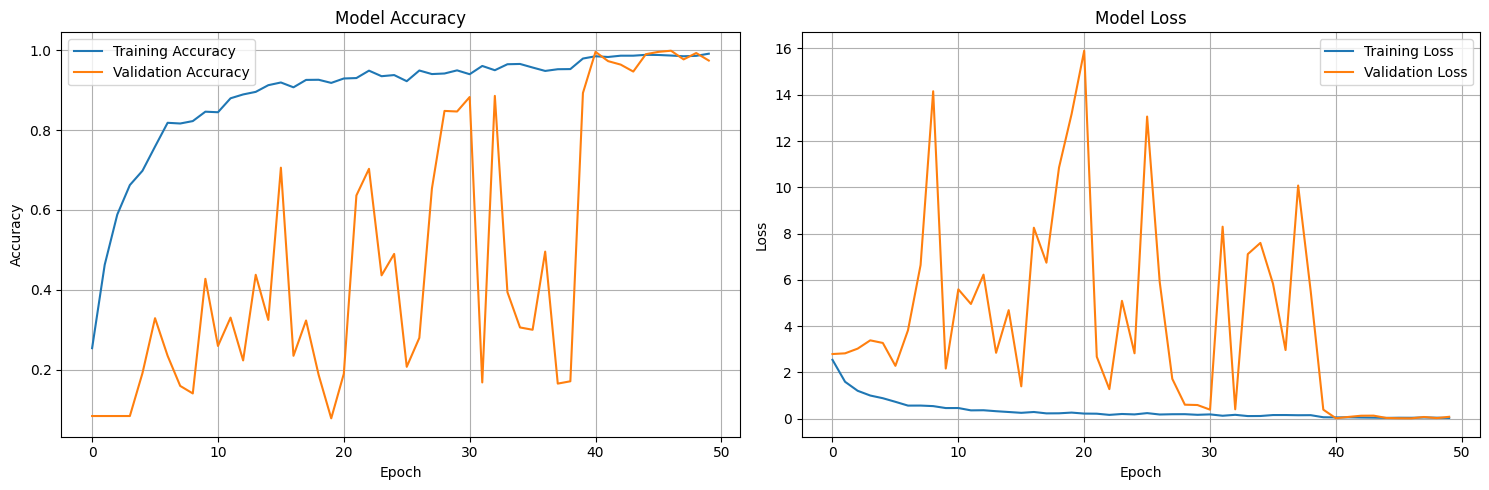

Generating confusion matrix...


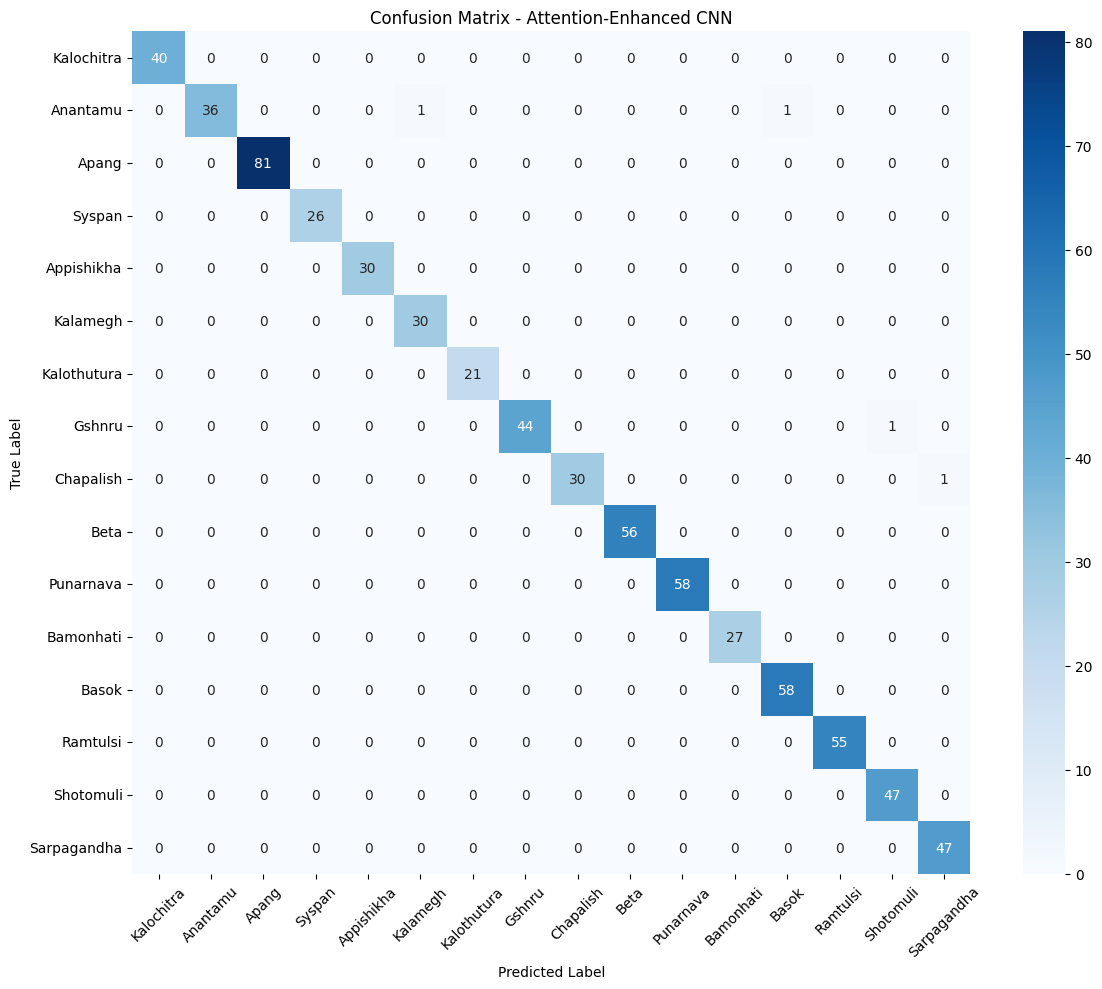

Generating ROC curves...


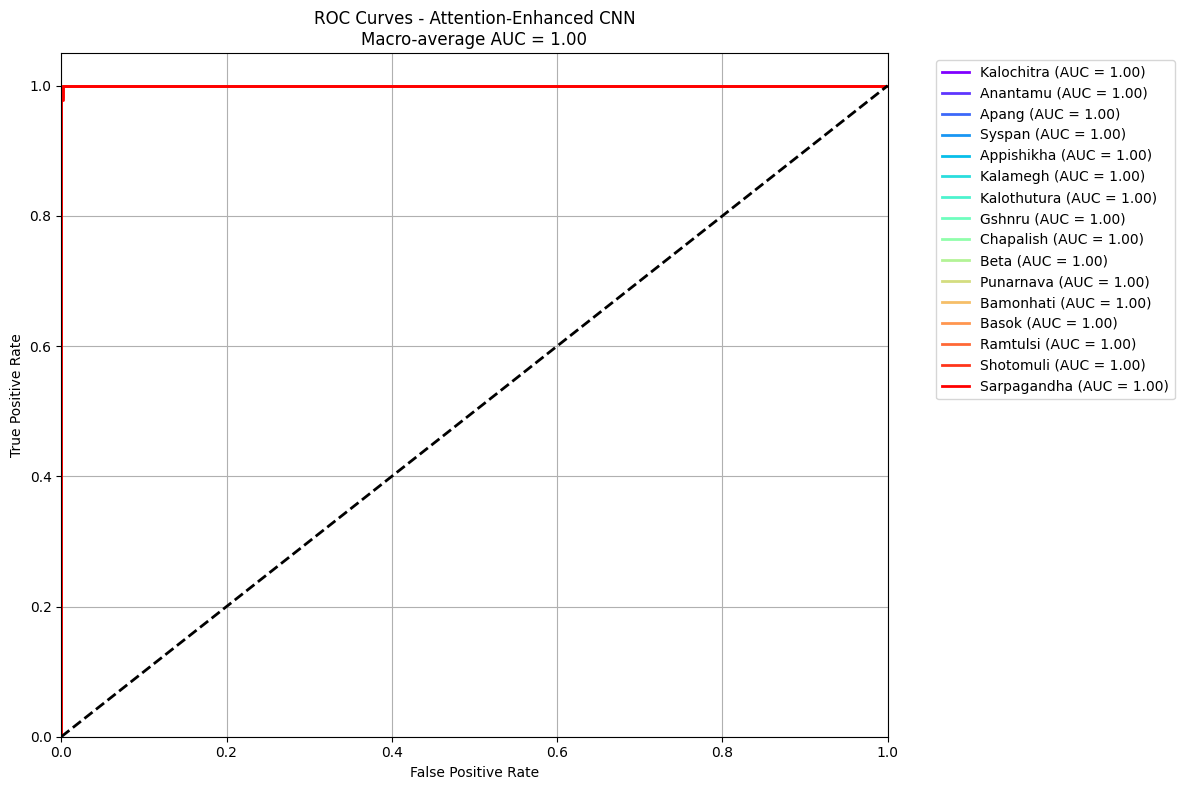

All visualizations completed!


In [9]:
print("Generating training history plot...")
plot_training_history(history)

print("Generating confusion matrix...")
plot_confusion_matrix(results['confusion_matrix'], class_names)

print("Generating ROC curves...")
plot_roc_curve(results['fpr'], results['tpr'], results['roc_auc'], 
              results['macro_auc'], class_names)

print("All visualizations completed!")

# Detailed Metrics Report

In [10]:
def print_detailed_metrics(results, class_names):
    print("\n" + "="*80)
    print("ATTENTION-ENHANCED CNN MODEL - COMPREHENSIVE EVALUATION")
    print("="*80)
    
    print(f"\nOverall Metrics:")
    print(f"  Accuracy: {results['val_accuracy']:.4f}")
    print(f"  Precision: {results['val_precision']:.4f}")
    print(f"  Recall: {results['val_recall']:.4f}")
    print(f"  F1-Score: {results['val_f1']:.4f}")
    print(f"  Macro-average AUC: {results['macro_auc']:.4f}")
    print(f"  Training Time: {results['training_time']:.2f} seconds")
    print(f"  Testing Time: {results['testing_time']:.2f} seconds")
    
    print(f"\nClass-wise Performance:")
    print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'AUC':<10}")
    print("-" * 55)
    for i, class_name in enumerate(class_names):
        precision = results['classification_report'][class_name]['precision']
        recall = results['classification_report'][class_name]['recall']
        f1 = results['classification_report'][class_name]['f1-score']
        class_auc = results['roc_auc'][i]
        print(f"{class_name:<15} {precision:<10.4f} {recall:<10.4f} {f1:<10.4f} {class_auc:<10.4f}")
    
    # Calculate and print macro averages
    macro_precision = results['classification_report']['macro avg']['precision']
    macro_recall = results['classification_report']['macro avg']['recall']
    macro_f1 = results['classification_report']['macro avg']['f1-score']
    
    print(f"\nMacro Averages:")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall: {macro_recall:.4f}")
    print(f"  F1-Score: {macro_f1:.4f}")
    print(f"  AUC: {results['macro_auc']:.4f}")

# Print detailed results
print_detailed_metrics(results, class_names)


ATTENTION-ENHANCED CNN MODEL - COMPREHENSIVE EVALUATION

Overall Metrics:
  Accuracy: 0.9971
  Precision: 0.9971
  Recall: 0.9971
  F1-Score: 0.9971
  Macro-average AUC: 1.0000
  Training Time: 2441.03 seconds
  Testing Time: 13.11 seconds

Class-wise Performance:
Class           Precision  Recall     F1-Score   AUC       
-------------------------------------------------------
Kalochitra      1.0000     1.0000     1.0000     1.0000    
Anantamu        1.0000     0.9474     0.9730     1.0000    
Apang           1.0000     1.0000     1.0000     1.0000    
Syspan          1.0000     1.0000     1.0000     1.0000    
Appishikha      1.0000     1.0000     1.0000     1.0000    
Kalamegh        0.9677     1.0000     0.9836     1.0000    
Kalothutura     1.0000     1.0000     1.0000     1.0000    
Gshnru          1.0000     0.9778     0.9888     1.0000    
Chapalish       1.0000     0.9677     0.9836     1.0000    
Beta            1.0000     1.0000     1.0000     1.0000    
Punarnava       1.

# Save Final Model and Results

In [11]:
# Save the final model
model.save('attention_enhanced_cnn_final.h5')
print("\nFinal model saved as 'attention_enhanced_cnn_final.h5'")

# Save results for comparison with other tasks
import pickle
with open('attention_model_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Results saved as 'attention_model_results.pkl'")

print("\n" + "="*50)
print("TASK 4 COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"Final Validation Accuracy: {results['val_accuracy']:.4f}")
print(f"Final Macro AUC: {results['macro_auc']:.4f}")
print(f"Training completed in {results['training_time']:.2f} seconds")


Final model saved as 'attention_enhanced_cnn_final.h5'
Results saved as 'attention_model_results.pkl'

TASK 4 COMPLETED SUCCESSFULLY!
Final Validation Accuracy: 0.9971
Final Macro AUC: 1.0000
Training completed in 2441.03 seconds
